# Tutorial 5 · From links and gauges to 2D rain maps

A commercial microwave link (CML) measures the rain **averaged along its path**; a rain gauge
or a personal weather station (PWS) measures it **at a point**. A map needs a value in every
grid cell. This tutorial builds that step by step, writing each method by hand before calling
the library version, so that the assumptions behind every map are visible:

| section | method | what it assumes about a link |
|---|---|---|
| 3 | inverse-distance weighting (IDW) from link midpoints | a point at the midpoint |
| 4 | line IDW (virtual gauges along each path) | uniform rain along the path |
| 5 | GMZ (Goldshtein, Messer & Zinevich 2009) | path average kept, distribution along the path free |
| 6 | ordinary kriging (OK) at midpoints | a point, with a fitted spatial covariance |
| 7 | block kriging | a line: covariances averaged over the path |
| 8 | gauge maps | (points only) |

Sections 9-10 score every map against the radar and against gauges, with leave-one-out
cross-validation where the gauges are also the input, and show how much the parameters matter.

**Data.** The OpenMRG example subset (Gothenburg, Sweden, 22-29 July 2015; Andersson et al.
2022), downloaded automatically on first use (about 28 MB) from
[OpenSenseAction/opensense_example_data](https://github.com/OpenSenseAction/opensense_example_data).
The link rain rates used here are the subset's own reference retrieval (variable `R`); how they
are computed from the received signal is the subject of tutorial 02. Everything is hourly:
the *storm hour* is 03:00-04:00 UTC on 26 July 2015, the *event* the 48 hours of 25-26 July.

**Prerequisites:** tutorial 01 (the datasets). **Runtime:** about two minutes.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import poligrain as plg
import xarray as xr

from core.opensense import example_data

warnings.filterwarnings("ignore", category=RuntimeWarning)   # empty-category means in poligrain
plt.rcParams.update({"figure.dpi": 100, "axes.grid": False})

EVENT = slice("2015-07-25", "2015-07-26")
STORM_HOUR = pd.Timestamp("2015-07-26 04:00")    # hour-ending label: 03:00-04:00 UTC

data = example_data.load("openmrg", "8d", time=EVENT)
cml, radar_5min = data["cml"], data["radar"]
gauge_city, gauge_smhi = data["gauge_municipal"], data["gauge_smhi"]

  [skip]  openmrg_cml_8d.nc  (26.87 MB, already present)


  [skip]  openmrg_rad_8d.nc  (1.25 MB, already present)


  [skip]  openmrg_municp_gauge_8d.nc  (0.13 MB, already present)


  [skip]  openmrg_smhi_gauge_8d.nc  (0.02 MB, already present)


## 1. Grid, projection and hourly data

Distances must be in metres, so every method works in a projected coordinate system. OpenMRG
ships all sensors in **UTM zone 32N** ([EPSG:32632](https://epsg.io/32632)): links as
`site_0_x/y`, `site_1_x/y`, gauges as `x/y` and the radar as the 2D arrays `x_grid/y_grid`
(the radar's own grid is polar stereographic, 2 km). We use the radar grid as the map grid,
which makes the radar a ready reference. FieldSense's own functions (`core.maps`) instead use
a regular latitude/longitude grid (`core.geo.Grid`) and project locally with
`core.geo.to_local_xy`; section 3 shows both give the same weights.

Time convention: every hourly value is labelled with the **end** of its hour
(`resample(..., label="right", closed="right")`), so 04:00 means 03:00-04:00 UTC.

* **Links:** the mean of the two sublinks' rain rate (mm/h, 10 s), averaged over each hour
  -> mm per hour. Hours with less than 80% of the samples are left empty.
* **Radar:** SMHI composite rain rate (mm/h, 5 min, Z = 200 R^1.5), averaged per hour -> mm.
* **Gauges:** 10 municipal gauges (1-min amounts) and the SMHI gauge (15-min amounts), summed
  per hour -> mm.

In [2]:
def hourly_mean(da, min_coverage=0.8):
    """Hour-ending mean of a rate series; hours with too few samples are NaN."""
    r = da.resample(time="1h", label="right", closed="right")
    step = pd.Series(da.time.values).diff().median()
    return r.mean().where(r.count() >= min_coverage * (pd.Timedelta("1h") / step))


# links: (link, time), mm per hour, with geometry for every method below
R = cml.R.mean("sublink_id")
first = cml.isel(sublink_id=0)
links = hourly_mean(R).rename(cml_id="link").transpose("link", "time")
links = links.assign_coords(
    x0=("link", cml.site_0_x.values), y0=("link", cml.site_0_y.values),
    x1=("link", cml.site_1_x.values), y1=("link", cml.site_1_y.values),
    site_0_lat=("link", cml.site_0_lat.values), site_0_lon=("link", cml.site_0_lon.values),
    site_1_lat=("link", cml.site_1_lat.values), site_1_lon=("link", cml.site_1_lon.values),
    frequency=("link", first.frequency_ghz.values.astype(float)),
    polarization=("link", np.where(np.char.startswith(first.polarization.values.astype(str), "v"), "v", "h")),
    length_km=("link", cml.length_km.values.astype(float)))
links = links.assign_coords(xm=(links.x0 + links.x1) / 2, ym=(links.y0 + links.y1) / 2,
                            mid_lat=(links.site_0_lat + links.site_1_lat) / 2,
                            mid_lon=(links.site_0_lon + links.site_1_lon) / 2)
links = links.isel(link=np.flatnonzero(links.notnull().any("time").values))

# radar: (time, y, x), mm per hour, on its native 2 km grid with UTM coordinates
radar = hourly_mean(radar_5min.R).sel(time=links.time)
XG, YG = radar.x_grid.values, radar.y_grid.values          # (ny, nx) metres
cells_xy = np.column_stack([XG.ravel(), YG.ravel()])

# gauges: (station, time), mm per hour
city = gauge_city.rainfall_amount.resample(time="1h", label="right", closed="right").sum(min_count=1)
smhi = gauge_smhi.rainfall_amount.resample(time="1h", label="right", closed="right").sum(min_count=1)
gauges = xr.concat([city, smhi], dim="id").rename(id="station").sel(time=links.time)
gauges = gauges.assign_coords(gx=("station", np.r_[gauge_city.x.values, gauge_smhi.x.values]),
                              gy=("station", np.r_[gauge_city.y.values, gauge_smhi.y.values]))

print(f"{links.sizes['link']} links, {gauges.sizes['station']} gauges, "
      f"radar grid {radar.sizes['y']} x {radar.sizes['x']} cells, {links.sizes['time']} hours")

353 links, 11 gauges, radar grid 48 x 37 cells, 49 hours


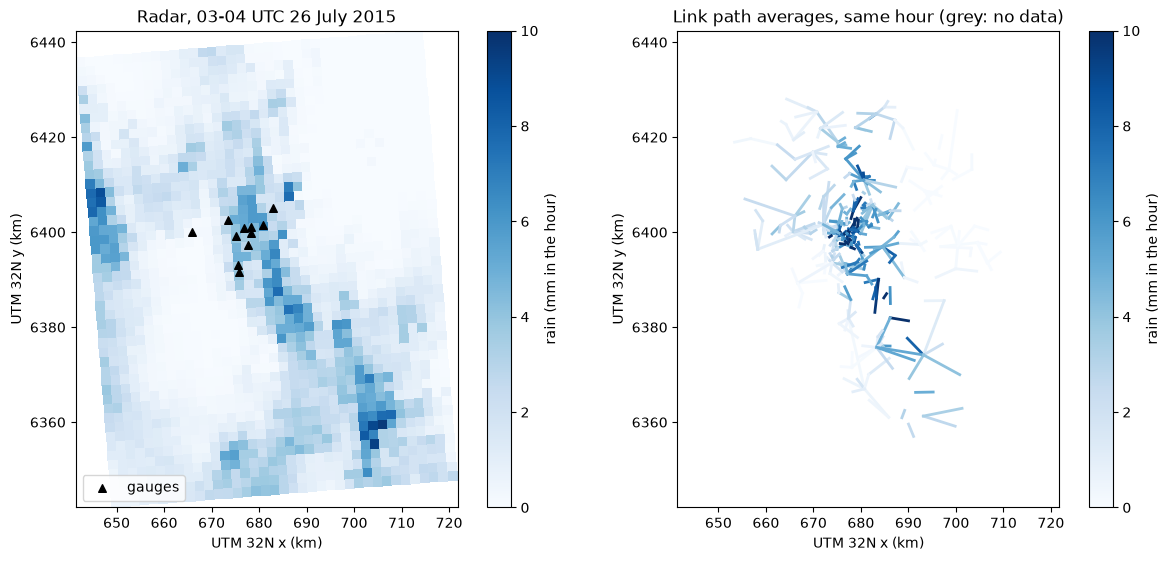

In [3]:
storm_links = links.sel(time=STORM_HOUR)
fig, ax = plt.subplots(1, 2, figsize=(12, 5.5), constrained_layout=True)
pm = ax[0].pcolormesh(XG / 1e3, YG / 1e3, radar.sel(time=STORM_HOUR), cmap="Blues", vmin=0, vmax=10, shading="auto")
for a in ax:
    a.set_aspect("equal"); a.set_xlabel("UTM 32N x (km)"); a.set_ylabel("UTM 32N y (km)")
ax[0].scatter(gauges.gx / 1e3, gauges.gy / 1e3, c="k", marker="^", s=30, label="gauges")
ax[0].legend(loc="lower left"); ax[0].set_title("Radar, 03-04 UTC 26 July 2015")
fig.colorbar(pm, ax=ax[0], label="rain (mm in the hour)")
norm = plt.Normalize(0, 10)
for i in range(links.sizes["link"]):
    v = float(storm_links[i])
    ax[1].plot([links.x0[i] / 1e3, links.x1[i] / 1e3], [links.y0[i] / 1e3, links.y1[i] / 1e3],
               color=plt.cm.Blues(norm(v)) if np.isfinite(v) else "0.8", lw=2)
ax[1].set_xlim(ax[0].get_xlim()); ax[1].set_ylim(ax[0].get_ylim())
ax[1].set_title("Link path averages, same hour (grey: no data)")
fig.colorbar(plt.cm.ScalarMappable(norm, "Blues"), ax=ax[1], label="rain (mm in the hour)");

## 2. A helper: scoring a map

Two references, neither of them ground truth:

* the **radar**, cell by cell - it covers everything but is an indirect estimate;
* the **gauges**, at the cell that contains each gauge - direct but only 11 points.

The scores come from `poligrain.validation.calculate_rainfall_metrics`
([poligrain docs](https://poligrain.readthedocs.io)): Pearson correlation, RMSE, MAE and
percent bias, here on all pairs where both values exist (threshold 0 mm). Against the radar
we keep only cells within 2 km of a link midpoint, where a link map can be expected to know
something.

In [4]:
from scipy.spatial import cKDTree

gauge_cell = cKDTree(cells_xy).query(np.column_stack([gauges.gx, gauges.gy]))[1]
near_links = cKDTree(np.column_stack([links.xm, links.ym])).query(cells_xy)[0] <= 2_000


def metrics(ref, est):
    ref, est = np.ravel(ref), np.ravel(est)
    m = plg.validation.calculate_rainfall_metrics(reference=ref, estimate=est)
    return {"corr": m["pearson_correlation_coefficient"], "RMSE (mm)": m["root_mean_square_error"],
            "bias (%)": m["percent_bias"], "n": int(np.sum(np.isfinite(ref) & np.isfinite(est)))}


def score(maps, name):
    """maps: (time, cell) mm. Scores against the radar near links and at the gauges."""
    maps = np.asarray(maps).reshape(len(links.time), -1)
    rad = radar.values.reshape(len(links.time), -1)
    out = {f"radar {k}": v for k, v in metrics(rad[:, near_links], maps[:, near_links]).items() if k != "n"}
    out.update({f"gauges {k}": v for k, v in metrics(gauges.values.T, maps[:, gauge_cell]).items() if k != "n"})
    return pd.Series(out, name=name)

## 3. Inverse-distance weighting from link midpoints

Each grid cell gets a weighted mean of the observations around it, with weights falling with
distance $d_i$:

$$\hat R(\mathbf{x}) = \frac{\sum_i w_i\, r_i}{\sum_i w_i}, \qquad w_i = d_i^{-p},$$

restricted to observations within a radius $d_{\max}$ and, optionally, to the $k$ nearest.
For a link, $r_i$ is its path average placed at its midpoint. $p$ controls how local the map
is: $p\to 0$ approaches the plain mean, large $p$ approaches nearest neighbour. IDW cannot
produce a value outside the range of its inputs, and it ignores how the observations are
arranged (two links side by side count twice).

First by hand, vectorised over all cells and hours: a weight matrix `W` of shape
(cells, links) is computed once, and a missing link value simply drops out of both the
numerator and the denominator of that hour.

In [5]:
def idw_weights(src_xy, dst_xy, p=2.0, radius=10_000.0, nnear=None):
    d = np.hypot(dst_xy[:, None, 0] - src_xy[None, :, 0], dst_xy[:, None, 1] - src_xy[None, :, 1])
    w = 1.0 / np.maximum(d, 1.0) ** p                 # 1 m floor: a cell on a source takes its value
    w[d > radius] = 0.0
    if nnear is not None and nnear < d.shape[1]:
        far = np.argsort(d, axis=1)[:, nnear:]
        np.put_along_axis(w, far, 0.0, axis=1)
    return w


def idw_apply(W, values):
    """W (cells, n), values (n, time) with NaN -> (time, cells); empty cells NaN."""
    ok = np.isfinite(values)
    num, den = W @ np.where(ok, values, 0.0), W @ ok
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(den > 0, num / den, np.nan).T


mid_xy = np.column_stack([links.xm, links.ym])
W_mid = idw_weights(mid_xy, cells_xy, p=2, radius=10_000)
idw_mid = idw_apply(W_mid, links.values)                     # (time, cells)

The same weights come out of FieldSense's `core.maps.idw.idw_weights` (here with the exact-hit
rule instead of a 1 m floor, which only matters for a cell centre lying on a midpoint).
`core.maps.idw.idw_map` wraps the whole computation for `(link, time)` arrays on a regular
lat/lon grid, which is what the projects use:

In [6]:
from core.geo import Domain, Grid
from core.maps.idw import idw_map, idw_weights as core_idw_weights

W_core = core_idw_weights(mid_xy[:, 0], mid_xy[:, 1], cells_xy[:, 0], cells_xy[:, 1], power=2, radius_m=10_000)
print("hand-written vs core.maps weights, max relative difference:",
      float(np.nanmax(np.abs(W_core - W_mid) / np.maximum(W_mid, 1e-30))))

grid_ll = Grid.from_domain(Domain.around(links.mid_lat, links.mid_lon, pad_deg=0.02), res_deg=0.01)
idw_ll = idw_map(links.sel(time=[STORM_HOUR]), grid_ll, power=2, radius_m=10_000)
print("core.maps.idw.idw_map on a 0.01 deg lat/lon grid:", dict(idw_ll.sizes))

hand-written vs core.maps weights, max relative difference: 0.0


core.maps.idw.idw_map on a 0.01 deg lat/lon grid: {'time': 1, 'lat': 66, 'lon': 91}


## 4. Line IDW: virtual gauges along each path

A midpoint ignores the length of the link: a 10 km link says nothing about rain at its ends.
The simplest fix replaces each link by $k$ **virtual gauges** spread evenly along the path,
each carrying the link's path average ($k$ = one per km, at least 3), and interpolates those.
Long links now inform the cells along their whole path. The assumption has moved, not gone:
rain is taken as uniform along each path.

In [7]:
def virtual_gauges(per_km=1.0, k_min=3):
    xs, ys, owner = [], [], []
    for i in range(links.sizes["link"]):
        n = max(k_min, int(np.ceil(per_km * float(links.length_km[i]))))
        s = np.linspace(0, 1, n)
        xs.append(float(links.x0[i]) + s * float(links.x1[i] - links.x0[i]))
        ys.append(float(links.y0[i]) + s * float(links.y1[i] - links.y0[i]))
        owner.append(np.full(n, i))
    return np.column_stack([np.concatenate(xs), np.concatenate(ys)]), np.concatenate(owner)


vg_xy, vg_owner = virtual_gauges()
W_line = idw_weights(vg_xy, cells_xy, p=2, radius=10_000)
idw_line = idw_apply(W_line, links.values[vg_owner])
print(f"{links.sizes['link']} links -> {len(vg_owner)} virtual gauges")

353 links -> 1400 virtual gauges


## 5. GMZ: let the rain vary along each path

Goldshtein, Messer & Zinevich (2009) keep the virtual gauges but drop the uniformity
assumption. Starting from line IDW, they iterate:

1. interpolate a field from the virtual gauges;
2. read the field back at each virtual gauge - the rain its **neighbours** suggest there;
3. shift each link's virtual gauges so that, in the attenuation domain, their mean equals the
   link's own measurement. Attenuation is linear in $R^b$ (ITU-R P.838, $A = aR^bL$), so the
   constraint is $\frac1k\sum_j \hat r_j^{\,b} = r_{\text{link}}^{\,b}$:

$$u_j \leftarrow r_{\text{link}}^{\,b} - \overline{\hat r^{\,b}} + \hat r_j^{\,b}, \qquad r_j = \max(u_j,0)^{1/b}.$$

After a few passes the rain along a link leans towards its neighbours while the link's
measurement is preserved. Below, step 2 reads the nearest grid cell; FieldSense's
`core.maps.gmz.gmz_map` reads the field bilinearly and follows PyNNcml's implementation
(10 passes). $b$ comes from the ITU-R P.838-3 tables via `core.cml.power_law.itu_ab`.

In [8]:
from core.cml.power_law import itu_ab

_, b_link = itu_ab(np.clip(links.frequency.values, 1, 100), links.polarization.values)
b_vg = b_link[vg_owner][:, None]
vg_cell = cKDTree(cells_xy).query(vg_xy)[1]


def gmz(values, n_iter=10):
    """values (link, time) -> (time, cells)."""
    valid = np.isfinite(values)[vg_owner]
    target = np.where(np.isfinite(values), np.clip(values, 0, None), 0.0) ** b_link[:, None]
    counts = np.bincount(vg_owner, minlength=values.shape[0])[:, None]
    pts = np.where(valid, np.nan_to_num(values)[vg_owner], np.nan)
    field = idw_apply(W_line, pts)                                   # line IDW
    for _ in range(n_iter):
        rb = np.clip(np.nan_to_num(field.T[vg_cell]), 0, None) ** b_vg
        mean_rb = np.zeros_like(target)
        np.add.at(mean_rb, vg_owner, rb)
        u = target[vg_owner] - (mean_rb / counts)[vg_owner] + rb
        pts = np.where(valid, np.clip(u, 0, None) ** (1 / b_vg), np.nan)
        field = idw_apply(W_line, pts)
    return field


gmz_map_hand = gmz(links.values)

## 6. Ordinary kriging

IDW's weights depend on distance only. **Kriging** chooses the weights that minimise the
expected squared error, given a model of how rain at two points co-varies with their
separation $h$ - the **semivariogram**

$$\gamma(h) = \tfrac12\,\mathrm{E}\big[(Z(\mathbf{x}) - Z(\mathbf{x}+\mathbf{h}))^2\big].$$

Its three parameters: the **nugget** (variance at zero distance: measurement error and
sub-grid variability), the **sill** (total variance) and the **range** (distance beyond which
two values are unrelated). Ordinary kriging assumes an unknown but locally constant mean.

### 6.1 Empirical variogram and model fit

From the link midpoints of the storm hour: half the squared difference of every pair, averaged
in distance bins, then a spherical and an exponential model fitted by least squares.

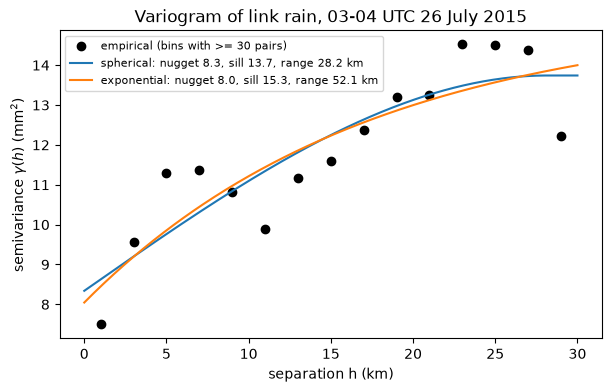

In [9]:
from scipy.optimize import curve_fit
from scipy.spatial.distance import pdist


def spherical(h, nugget, sill, rng):
    h = np.asarray(h, float)
    g = nugget + (sill - nugget) * (1.5 * h / rng - 0.5 * (h / rng) ** 3)
    return np.where(h < rng, g, sill) * (h > 0)


def exponential(h, nugget, sill, rng):
    h = np.asarray(h, float)
    return (nugget + (sill - nugget) * (1 - np.exp(-3 * h / rng))) * (h > 0)


ok = np.isfinite(storm_links.values)
z, xy = storm_links.values[ok], mid_xy[ok]
lag, sv = pdist(xy), 0.5 * pdist(z[:, None], "sqeuclidean")
bins = np.arange(0, 30_001, 2_000)
idx = np.digitize(lag, bins) - 1
centers = 0.5 * (bins[1:] + bins[:-1])
gamma_emp = np.array([sv[idx == i].mean() if np.any(idx == i) else np.nan for i in range(len(centers))])
npairs = np.bincount(idx[idx < len(centers)], minlength=len(centers))

good = np.isfinite(gamma_emp) & (npairs >= 30)
p0, bounds = [0.1 * z.var(), z.var(), 10_000], ([0, 0, 500], [np.inf, np.inf, 60_000])
fit_sph, _ = curve_fit(spherical, centers[good], gamma_emp[good], p0=p0, bounds=bounds)
fit_exp, _ = curve_fit(exponential, centers[good], gamma_emp[good], p0=p0, bounds=bounds)

h = np.linspace(1, 30_000, 300)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(centers[good] / 1e3, gamma_emp[good], "ko", label="empirical (bins with >= 30 pairs)")
ax.plot(h / 1e3, spherical(h, *fit_sph), label="spherical: nugget %.1f, sill %.1f, range %.1f km" % (fit_sph[0], fit_sph[1], fit_sph[2] / 1e3))
ax.plot(h / 1e3, exponential(h, *fit_exp), label="exponential: nugget %.1f, sill %.1f, range %.1f km" % (fit_exp[0], fit_exp[1], fit_exp[2] / 1e3))
ax.set_xlabel("separation h (km)"); ax.set_ylabel(r"semivariance $\gamma(h)$ (mm$^2$)")
ax.set_title("Variogram of link rain, 03-04 UTC 26 July 2015"); ax.legend(fontsize=8);

### 6.2 The kriging system, by hand

For a target $\mathbf{x}_0$ and $n$ observations, the weights $\lambda_i$ and a Lagrange
multiplier $\mu$ (which enforces $\sum\lambda_i = 1$, i.e. no bias) solve

$$\begin{pmatrix} \gamma(\mathbf{x}_i,\mathbf{x}_j) & \mathbf{1} \\ \mathbf{1}^\top & 0 \end{pmatrix}
\begin{pmatrix} \boldsymbol\lambda \\ \mu \end{pmatrix} =
\begin{pmatrix} \gamma(\mathbf{x}_i,\mathbf{x}_0) \\ 1 \end{pmatrix},
\qquad \hat Z(\mathbf{x}_0) = \sum_i \lambda_i z_i .$$

Here for one grid cell from its five nearest links. Unlike IDW, a weight can be negative, and
two links close together share the weight one of them would have had alone (declustering).

In [10]:
def gamma_model(h, model=fit_sph):
    return spherical(h, *model)


target = cells_xy[np.argmax(radar.sel(time=STORM_HOUR).values.ravel())]
d0 = np.hypot(*(xy - target).T)
near5 = np.argsort(d0)[:5]
P = xy[near5]
A = np.ones((6, 6)); A[5, 5] = 0
A[:5, :5] = gamma_model(np.hypot(P[:, None, 0] - P[None, :, 0], P[:, None, 1] - P[None, :, 1]))
b = np.r_[gamma_model(d0[near5]), 1.0]
sol = np.linalg.solve(A, b)
lam = sol[:5]
idw5 = 1 / d0[near5] ** 2; idw5 /= idw5.sum()
print(pd.DataFrame({"distance (km)": d0[near5] / 1e3, "value (mm)": z[near5],
                    "kriging weight": lam, "IDW weight (p=2)": idw5}).round(3).to_string())
print(f"sum of kriging weights = {lam.sum():.3f};  kriged value = {lam @ z[near5]:.2f} mm, "
      f"IDW value = {idw5 @ z[near5]:.2f} mm")

   distance (km)  value (mm)  kriging weight  IDW weight (p=2)
0          9.217       3.352           0.246             0.329
1          9.580       2.733           0.243             0.305
2         14.431       5.034           0.142             0.134
3         15.530       2.590           0.167             0.116
4         15.561       4.133           0.202             0.116
sum of kriging weights = 1.000;  kriged value = 3.47 mm, IDW value = 3.39 mm


### 6.3 The whole map

The same system for every cell, using its 12 nearest observations (local kriging, as in
`mergeplg`), solved in one batched call. Missing observations of an hour are removed before
the neighbours are chosen.

In [11]:
def krige(obs_xy, values, dst_xy, model=fit_sph, nnear=12):
    """Point ordinary kriging. values (n, time) -> (time, cells)."""
    out = np.full((values.shape[1], len(dst_xy)), np.nan)
    for t in range(values.shape[1]):
        ok = np.isfinite(values[:, t])
        if ok.sum() < 3:
            continue
        P, v = obs_xy[ok], values[ok, t]
        k = min(nnear, len(v))
        d, ind = cKDTree(P).query(dst_xy, k=k)
        G = gamma_model(np.hypot(P[ind][:, :, None, 0] - P[ind][:, None, :, 0],
                                 P[ind][:, :, None, 1] - P[ind][:, None, :, 1]), model)
        A = np.ones((len(dst_xy), k + 1, k + 1)); A[:, k, k] = 0; A[:, :k, :k] = G
        b = np.concatenate([gamma_model(d, model), np.ones((len(dst_xy), 1))], axis=1)
        lam = np.linalg.solve(A, b[..., None])[:, :k, 0]
        out[t] = np.einsum("ck,ck->c", lam, v[ind])
    return out


ok_mid = krige(mid_xy, links.values, cells_xy)

`pykrige` ([docs](https://geostat-framework.readthedocs.io/projects/pykrige)) solves the same
system with *all* observations at once (global kriging); with the same variogram the two maps
agree closely where links are dense and differ where the 12 nearest links are far away:

In [12]:
from pykrige.ok import OrdinaryKriging

okp = OrdinaryKriging(xy[:, 0], xy[:, 1], z, variogram_model="spherical",
                      variogram_parameters={"psill": fit_sph[1] - fit_sph[0], "range": fit_sph[2], "nugget": fit_sph[0]})
z_pk, _ = okp.execute("points", cells_xy[:, 0], cells_xy[:, 1])
t_storm = int(np.flatnonzero(links.time.values == np.datetime64(STORM_HOUR))[0])
both = near_links
print("local (12 nearest) vs global kriging, cells within 2 km of a link: correlation %.3f, "
      "mean absolute difference %.2f mm" % (np.corrcoef(z_pk[both], ok_mid[t_storm][both])[0, 1],
                                            np.mean(np.abs(z_pk[both] - ok_mid[t_storm][both]))))

local (12 nearest) vs global kriging, cells within 2 km of a link: correlation 0.980, mean absolute difference 0.32 mm


## 7. Block kriging: a link is a line

Kriging needs the covariance between every pair of observations and between each observation
and the target. For a link these are not point-to-point: they are **averages over the path**.
Discretising each link into $m$ points, the block-to-block and block-to-point semivariances are

$$\bar\gamma(L_i, L_j) = \frac{1}{m^2}\sum_{a=1}^m\sum_{c=1}^m \gamma\big(|\mathbf{x}_{ia}-\mathbf{x}_{jc}|\big),
\qquad \bar\gamma(L_i, \mathbf{x}_0) = \frac{1}{m}\sum_{a=1}^m \gamma\big(|\mathbf{x}_{ia}-\mathbf{x}_0|\big).$$

A link's variance with itself is no longer zero: rain varies *within* the path, so a long link
is a smoothed observation, and the system weighs it accordingly. This is the method of the
OpenSense package [`mergeplg`](https://github.com/OpenSenseAction/mergeplg)
(`InterpolateOrdinaryKriging(full_line=True)`); `full_line=False` gives point kriging at the
midpoints. First the two semivariances for one pair of links, by hand:

In [13]:
def discretise(i, m=9):
    s = np.linspace(0, 1, m)
    return np.column_stack([float(links.x0[i]) + s * float(links.x1[i] - links.x0[i]),
                            float(links.y0[i]) + s * float(links.y1[i] - links.y0[i])])


long_links = np.argsort(links.length_km.values)[-2:]
Pa, Pb = discretise(long_links[0]), discretise(long_links[1])
pair = lambda P, Q: gamma_model(np.hypot(P[:, None, 0] - Q[None, :, 0], P[:, None, 1] - Q[None, :, 1])).mean()
print(f"links of {float(links.length_km[long_links[0]]):.1f} and {float(links.length_km[long_links[1]]):.1f} km:")
print(f"  midpoint-to-midpoint gamma = {gamma_model(np.hypot(*(Pa[4] - Pb[4]))):.2f} mm^2,"
      f"  block-to-block gamma = {pair(Pa, Pb):.2f} mm^2,  within-block gamma of the first = {pair(Pa, Pa):.2f} mm^2")

links of 14.8 and 15.2 km:
  midpoint-to-midpoint gamma = 13.74 mm^2,  block-to-block gamma = 13.65 mm^2,  within-block gamma of the first = 8.93 mm^2


Now the full maps with `mergeplg` (the PyPI release 0.1.0 installed in `.venv`), point and
block kriging with the variogram fitted above. `mergeplg` reads the geometry from
coordinate names: the grid needs `x_grid`/`y_grid`, the links `cml_id` and
`site_0_x/y`, `site_1_x/y`. Its `variogram_parameters` take the **total** sill (nugget
included) and run one hour at a time.

In [14]:
from mergeplg import interpolate as mrg_interpolate

grid_da = radar.sel(time=STORM_HOUR)
da_cml = (storm_links.rename(link="cml_id")
          .assign_coords(site_0_x=("cml_id", links.x0.values), site_0_y=("cml_id", links.y0.values),
                         site_1_x=("cml_id", links.x1.values), site_1_y=("cml_id", links.y1.values)))
da_cml = da_cml.isel(cml_id=np.flatnonzero(np.isfinite(da_cml.values)))
vparams = {"sill": float(fit_sph[1]), "range": float(fit_sph[2]), "nugget": float(fit_sph[0])}

storm_maps = {}
for name, full_line in [("point kriging (mergeplg)", False), ("block kriging (mergeplg)", True)]:
    interp = mrg_interpolate.InterpolateOrdinaryKriging(min_observations=1)
    storm_maps[name] = np.asarray(interp.interpolate(grid_da, da_cml=da_cml, variogram_model="spherical",
                                                     variogram_parameters=vparams, nnear=12,
                                                     full_line=full_line)).ravel()
print("hand-written point kriging vs mergeplg point kriging, max |difference| = %.3f mm"
      % np.nanmax(np.abs(storm_maps["point kriging (mergeplg)"] - ok_mid[t_storm])))

hand-written point kriging vs mergeplg point kriging, max |difference| = 0.000 mm


## 8. Maps from point gauges

The same tools apply to points. With 11 gauges over a 70 km domain, a gauge map is smooth by
necessity: IDW with a 30 km radius (10 km would leave most cells empty) and point kriging with
the link variogram. A PWS network enters exactly the same way after quality control (tutorial
06 and `core.opensense.pws_qc`).

In [15]:
g_xy = np.column_stack([gauges.gx, gauges.gy])
W_g = idw_weights(g_xy, cells_xy, p=2, radius=30_000)
idw_gauges = idw_apply(W_g, gauges.values)
ok_gauges = krige(g_xy, gauges.values, cells_xy, nnear=11)

## 9. How good are the maps?

### 9.1 The storm hour and the event total

IDW stops 10 km from the nearest observation (30 km for the gauges), while kriging, as set up
here, extrapolates over the whole domain; far from the links it tends to the local mean. The
scores below use only cells near links (radar) and gauge cells, so this does not affect them.

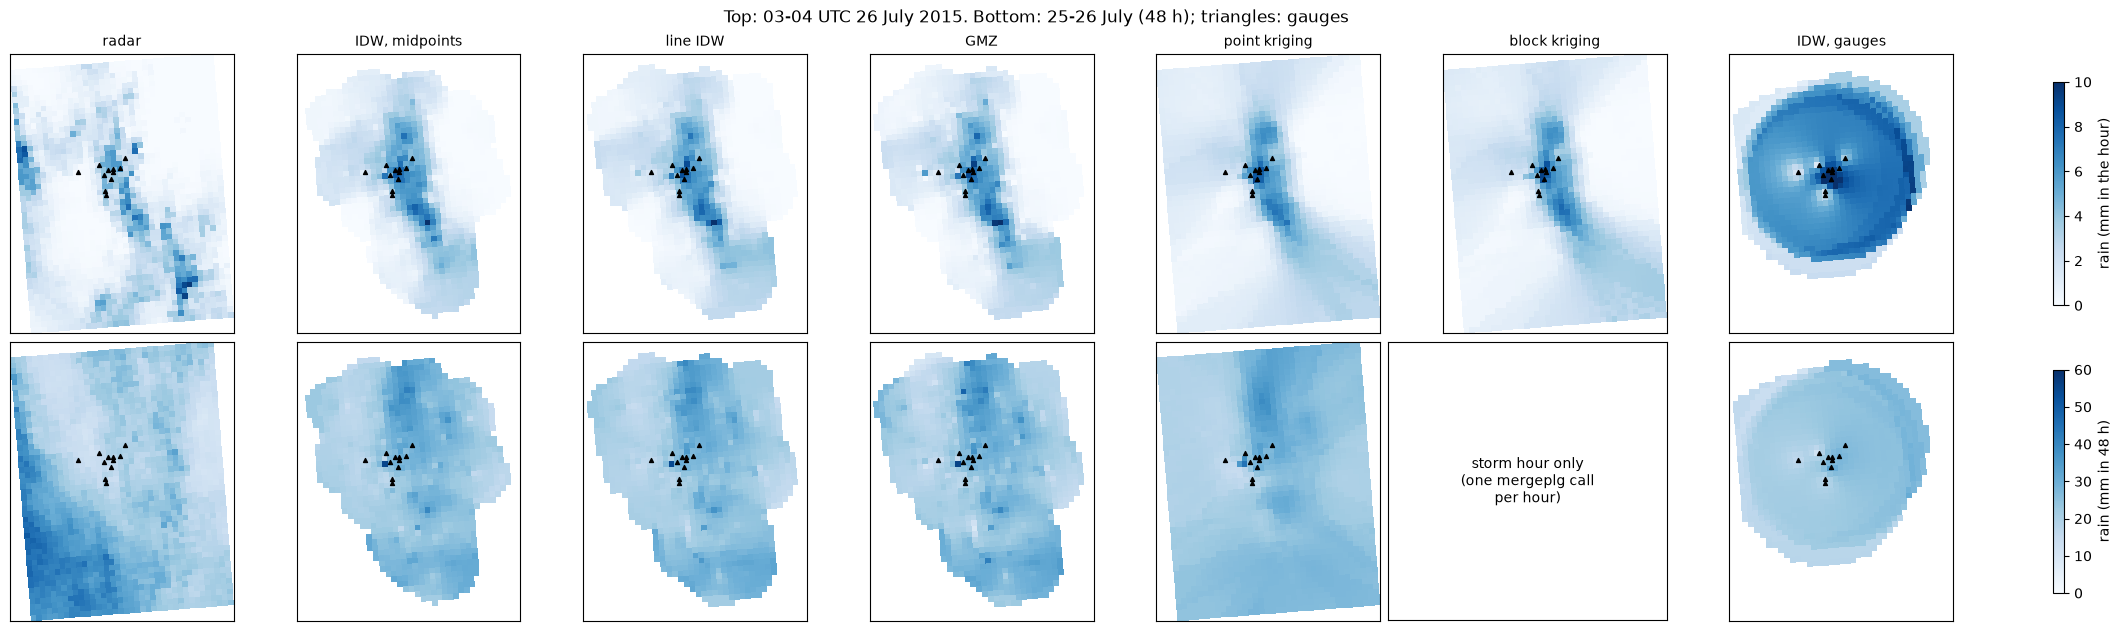

In [16]:
maps = {"IDW, midpoints": idw_mid, "line IDW": idw_line, "GMZ": gmz_map_hand,
        "point kriging": ok_mid, "IDW, gauges": idw_gauges}
shape = radar.shape[1:]
panels = [("radar", radar.sel(time=STORM_HOUR).values, radar.sum("time").values)]
panels += [(k, v[t_storm].reshape(shape), np.nansum(v, axis=0).reshape(shape) * np.where(np.isnan(v).all(0), np.nan, 1).reshape(shape))
           for k, v in maps.items()]
panels.insert(5, ("block kriging", storm_maps["block kriging (mergeplg)"].reshape(shape), None))

fig, axes = plt.subplots(2, len(panels), figsize=(3.1 * len(panels), 6.2), constrained_layout=True)
for j, (name, hour, total) in enumerate(panels):
    for i, (fld, vmax, lab) in enumerate([(hour, 10, "mm in the hour"), (total, 60, "mm in 48 h")]):
        a = axes[i, j]; a.set_xticks([]); a.set_yticks([]); a.set_aspect("equal")
        if fld is None:
            a.text(0.5, 0.5, "storm hour only\n(one mergeplg call\nper hour)", ha="center", va="center", transform=a.transAxes)
            continue
        pm = a.pcolormesh(XG, YG, fld, cmap="Blues", vmin=0, vmax=vmax, shading="auto")
        a.scatter(gauges.gx, gauges.gy, c="k", marker="^", s=8)
    axes[0, j].set_title(name, fontsize=10)
fig.colorbar(pm, ax=axes[1, :], shrink=0.8, label="rain (mm in 48 h)")
fig.colorbar(axes[0, 0].collections[0], ax=axes[0, :], shrink=0.8, label="rain (mm in the hour)")
fig.suptitle("Top: 03-04 UTC 26 July 2015. Bottom: 25-26 July (48 h); triangles: gauges");

### 9.2 Scores over the 48 hours

Link maps are scored against both references; the gauges are independent of them. A gauge map
scored at the gauges it was built from would be perfect by construction, so for the gauge maps
the gauge scores use **leave-one-out cross-validation**: each gauge is predicted from the
other ten, hour by hour.

In [17]:
def loo_gauges(method):
    pred = np.full(gauges.shape, np.nan)            # (station, time)
    for s in range(gauges.sizes["station"]):
        keep = np.arange(gauges.sizes["station"]) != s
        target = g_xy[[s]]
        if method == "idw":
            pred[s] = idw_apply(idw_weights(g_xy[keep], target, p=2, radius=30_000), gauges.values[keep])[:, 0]
        else:
            pred[s] = krige(g_xy[keep], gauges.values[keep], target, nnear=10)[:, 0]
    return pred


rows = [score(v, k) for k, v in maps.items() if k != "IDW, gauges"]
for name, field, method in [("IDW, gauges (LOO at gauges)", idw_gauges, "idw"),
                            ("kriging, gauges (LOO at gauges)", ok_gauges, "ok")]:
    s = score(field, name)
    loo = metrics(gauges.values, loo_gauges(method))
    s[["gauges corr", "gauges RMSE (mm)", "gauges bias (%)"]] = [loo["corr"], loo["RMSE (mm)"], loo["bias (%)"]]
    rows.append(s)
rad_g = metrics(gauges.values.T, radar.values.reshape(len(links.time), -1)[:, gauge_cell])
rows.append(pd.Series({"gauges corr": rad_g["corr"], "gauges RMSE (mm)": rad_g["RMSE (mm)"],
                       "gauges bias (%)": rad_g["bias (%)"]}, name="radar"))
table = pd.DataFrame(rows)
table.round(2)

,radar corr,radar RMSE (mm),radar bias (%),gauges corr,gauges RMSE (mm),gauges bias (%)
"IDW, midpoints",0.68,0.81,25.44,0.88,0.71,10.71
line IDW,0.69,0.80,23.15,0.87,0.72,9.59
GMZ,0.68,0.82,23.83,0.87,0.72,9.53
point kriging,0.69,0.79,24.61,0.91,0.61,10.72
"IDW, gauges (LOO at gauges)",0.41,1.18,18.85,0.84,0.80,4.34
"kriging, gauges (LOO at gauges)",0.44,1.04,10.61,0.80,0.86,1.10
radar,NaN,NaN,NaN,0.71,1.04,-24.55


How to read the table:

* The **radar columns** say how similar a map is to the radar near the links; the **gauge
  columns** how close it is at 11 independent points (hourly, so a few hundred gauge-hours).
  The two references disagree with each other too: the last row is the radar at the gauges,
  and on this event it reads about a quarter low there (bias about -25%), while the link maps
  read about 10% high. Against the radar, a link map therefore looks biased high even where it
  agrees with the gauges.
* Among the link maps, point kriging is closest to the gauges (RMSE about 0.6 mm against 0.7
  for the IDW variants); line IDW and GMZ hardly differ from midpoint IDW on this dense city
  network, where most links are short. On networks with longer links, and with the retrieval
  varied as well, `projects/multisensor_maps` finds the retrieval (tutorial 02) moves the
  scores several times more than the interpolation.
* Eleven gauges map the event worse than 353 links do, even scored fairly (leave-one-out).

## 10. How much do the parameters matter?

Scores at the gauges over the 48 hours, varying one parameter at a time from IDW with
$p = 2$, $d_{\max} = 10$ km, all neighbours, and kriging with the fitted range and nugget.

In [18]:
def gauge_rmse(field):
    return metrics(gauges.values.T, np.asarray(field)[:, gauge_cell])["RMSE (mm)"]


def gauge_corr(field):
    return metrics(gauges.values.T, np.asarray(field)[:, gauge_cell])["corr"]


g_cells = cells_xy[gauge_cell]                     # evaluate only where it is scored: fast
sens = []
for p in [1, 2, 3, 4]:
    f = idw_apply(idw_weights(mid_xy, g_cells, p=p, radius=10_000), links.values)
    sens.append(("IDW power p", p, f))
for r in [3_000, 5_000, 10_000, 20_000]:
    f = idw_apply(idw_weights(mid_xy, g_cells, p=2, radius=r), links.values)
    sens.append(("IDW radius (km)", r / 1e3, f))
for k in [2, 4, 8, 16, None]:
    f = idw_apply(idw_weights(mid_xy, g_cells, p=2, radius=10_000, nnear=k), links.values)
    sens.append(("IDW nearest k", k or "all", f))
for rng in [2_000, 5_000, 10_000, 30_000]:
    f = krige(mid_xy, links.values, g_cells, model=(fit_sph[0], fit_sph[1], rng))
    sens.append(("kriging range (km)", rng / 1e3, f))
for share in [0.0, 0.3, 0.6, 0.9]:
    f = krige(mid_xy, links.values, g_cells, model=(share * fit_sph[1], fit_sph[1], fit_sph[2]))
    sens.append(("kriging nugget / sill", share, f))

full = lambda f: np.pad(f, ((0, 0), (0, 0)))       # (time, gauges) already at the gauge cells
sens_table = pd.DataFrame([{"parameter": a, "value": v,
                            "RMSE at gauges (mm)": metrics(gauges.values.T, f)["RMSE (mm)"],
                            "corr at gauges": metrics(gauges.values.T, f)["corr"],
                            "gauge-hours mapped": metrics(gauges.values.T, f)["n"]} for a, v, f in sens])
sens_table.round(3).to_string(index=False)
print(sens_table.round(3).to_string(index=False))

            parameter value  RMSE at gauges (mm)  corr at gauges  gauge-hours mapped
          IDW power p     1                0.777           0.848                 528
          IDW power p     2                0.710           0.876                 528
          IDW power p     3                0.718           0.871                 528
          IDW power p     4                0.742           0.860                 528
      IDW radius (km)   3.0                0.681           0.886                 528
      IDW radius (km)   5.0                0.695           0.881                 528
      IDW radius (km)  10.0                0.710           0.876                 528
      IDW radius (km)  20.0                0.713           0.875                 528
        IDW nearest k     2                0.775           0.845                 528
        IDW nearest k     4                0.732           0.864                 528
        IDW nearest k     8                0.695           0.880 

On a sparser network a small radius would leave gauges far from links unmapped (the last
column would drop, and the score be computed on fewer, easier pairs); here every gauge is
within 3 km of a link, so all gauge-hours are mapped and a smaller radius - a more local map -
is slightly better. The power and the number of neighbours change the RMSE by about 10%. For
kriging the **nugget share** matters more than the range: a zero nugget forces the map through
every (noisy) link value and is clearly worse; the fitted nugget (about 60% of the sill) is
close to the best. A large nugget turns kriging into a local mean. Kriging weights do
not change when the whole variogram is scaled, so only its shape matters - which is why
`mergeplg` and `core.maps.mergeplg_methods` take the sill as 1 by default.

## Summary

* Every link map makes an assumption about where along the path the rain fell: at the
  midpoint (IDW, point kriging), uniformly (line IDW), or wherever the neighbours suggest
  (GMZ, block kriging).
* Kriging adds a model of spatial correlation, fitted from the data; its weights decluster
  observations and account for a link being a line (block kriging).
* Score against more than one reference and never at the gauges a map was built from.

Next: **tutorial 06** adds the radar - adjusting it to links and gauges instead of mapping the
links alone. The FieldSense projects that use these maps at scale:
[`multisensor_maps`](../projects/multisensor_maps/) (three networks, retrieval x
interpolation), [`nyc_rain_maps`](../projects/nyc_rain_maps/) and
[`cml_retrieval`](../projects/cml_retrieval/) (`rainfall_maps_idw_gmz.ipynb`).

## References and links

* Andersson, J. C. M., et al. (2022): OpenMRG: Open data from Microwave links, Radar, and
  Gauges for rainfall quantification in Gothenburg, Sweden. *Earth Syst. Sci. Data*, 14,
  5411-5426, [doi:10.5194/essd-14-5411-2022](https://doi.org/10.5194/essd-14-5411-2022);
  data: [doi:10.5281/zenodo.7107689](https://doi.org/10.5281/zenodo.7107689).
* Goldshtein, O., Messer, H. and Zinevich, A. (2009): Rain rate estimation using measurements
  from commercial telecommunications links. *IEEE Trans. Signal Process.*, 57(4), 1616-1625,
  [doi:10.1109/TSP.2009.2012554](https://doi.org/10.1109/TSP.2009.2012554).
* ITU-R P.838-3 (2005): Specific attenuation model for rain for use in prediction methods,
  [itu.int/rec/R-REC-P.838](https://www.itu.int/rec/R-REC-P.838/en).
* Graf, M., et al. (2021): Rainfall estimates from opportunistic sensors in Germany across
  spatio-temporal scales. *J. Hydrol. Reg. Stud.*, 37, 100883,
  [doi:10.1016/j.ejrh.2021.100883](https://doi.org/10.1016/j.ejrh.2021.100883) (block kriging of CMLs).
* Software: [mergeplg](https://github.com/OpenSenseAction/mergeplg),
  [poligrain](https://github.com/OpenSenseAction/poligrain)
  ([docs](https://poligrain.readthedocs.io)),
  [PyKrige](https://github.com/GeoStat-Framework/PyKrige),
  [PyNNcml](https://github.com/haihabi/PyNNcml) (GMZ),
  [OpenSense example data](https://github.com/OpenSenseAction/opensense_example_data).
* OpenSense Training School material on interpolation:
  [TrainingSchoolMergingApplication / os-merging-session](https://github.com/OpenSenseAction/TrainingSchoolMergingApplication/tree/main/os-merging-session).